In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.linear_model import Lasso

## 2. Data Preprocessing

In [7]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


## 3. Lasso and 1-SE Rule

In [8]:
def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

In [9]:
X_np = X.values
y_np = y_class.values

# numerical columns to standardize
num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

# for the repetitions of the outer cv
repetitions_rmse = []
repetitions_rmse_1se = []

# save hyperparameters from model selection
best_alphas = []
alphas_1se = []

# save selected features
n_selected_list = []
selection_counts = np.zeros(X.shape[1])
n_selected_list_1se = []
selection_counts_1se = np.zeros(X.shape[1])

outer_folds = 5
n_repeats = 10

# change composition of folds
for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    folds_rmse = []
    folds_rmse_1se = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]

        # impute numerical missing values using median of training fold
        X_out_train[:, num_idx] = np.where(
            np.isnan(X_out_train[:, num_idx]),
            np.nanmedian(X_out_train[:, num_idx], axis=0),
            X_out_train[:, num_idx]
        )
        # apply same median to test fold
        train_median = np.nanmedian(X_out_train[:, num_idx], axis=0)
        X_out_test[:, num_idx] = np.where(
            np.isnan(X_out_test[:, num_idx]),
            train_median,
            X_out_test[:, num_idx]
        )
        
        #for X: standardize only numerical features
        scaler = StandardScaler()
        X_out_train[:, num_idx] = scaler.fit_transform(X_out_train[:, num_idx])
        X_out_test[:, num_idx] = scaler.transform(X_out_test[:, num_idx])
        #for y: only center
        y_out_train_centered, mu = centerData(y_out_train)
        y_out_test_centered = y_out_test - mu

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            # automatic inner cv for model selection
            lasso_model = LassoCV(cv=5, fit_intercept=False, max_iter=10000, n_jobs=-1)
            lasso_model.fit(X_out_train, y_out_train_centered)

        best_alpha = lasso_model.alpha_
        best_alphas.append(best_alpha)

        # save for model with min mse
        # number of selected features
        coef_best = lasso_model.coef_
        selected = (coef_best != 0)
        n_selected_list.append(selected.sum())
        selection_counts += selected

        # evaluation on outer test set
        y_out_pred = X_out_test @ coef_best
        fold_rmse = np.sqrt(np.mean((y_out_pred - y_out_test_centered)**2))
        folds_rmse.append(fold_rmse)


        # 1 se rule
        mse_path = lasso_model.mse_path_ 
        mse_mean = np.mean(mse_path, axis=1)
        mse_std = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])

        # find alpha with lower mse mean
        min_idx = np.argmin(mse_mean)
        min_mse = mse_mean[min_idx]
        min_se = mse_std[min_idx]

        threshold = min_mse + min_se

        # find largest alpha with mse smaller than threshold
        alphas = lasso_model.alphas_
        one_se_idx = np.where(mse_mean <= threshold)[0] 
        alpha_1se = np.max(alphas[one_se_idx])
        alphas_1se.append(alpha_1se)

        lasso_1se = Lasso(alpha=alpha_1se,fit_intercept=False)
        lasso_1se.fit(X_out_train, y_out_train_centered)

        # number of selected features
        coef_1se = lasso_1se.coef_
        selected_1se = (coef_1se != 0)
        n_selected_list_1se.append(selected_1se.sum())
        selection_counts_1se += selected_1se

        # evaluation on outer test set
        y_out_pred_1se = X_out_test @ coef_1se
        fold_rmse_1se = np.sqrt(np.mean((y_out_pred_1se - y_out_test_centered)**2))
        folds_rmse_1se.append(fold_rmse_1se)

    repetitions_rmse.extend(folds_rmse)
    repetitions_rmse_1se.extend(folds_rmse_1se)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

print(f"Mean best_alpha: {np.mean(best_alphas):.4f}")
print(f"Std of best_alpha: {np.std(best_alphas):.4f}")

overall_std = np.std(repetitions_rmse)
print(f"Overall std: {overall_std:.4f}")




nested_cv_rmse_1se = np.mean(repetitions_rmse_1se)
nested_cv_std_1se = np.std(repetitions_rmse_1se) / np.sqrt(len(repetitions_rmse_1se))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse_1se:.4f} ± {nested_cv_std_1se:.4f}")

print(f"Mean alpha 1se: {np.mean(alphas_1se):.4f}")
print(f"Std alpha 1se: {np.std(alphas_1se):.4f}")

overall_std_1se = np.std(repetitions_rmse_1se)
print(f"Overall std: {overall_std_1se:.4f}")

Repeated Nested CV estimated RMSE: 33.9598 ± 0.6115
Mean best_alpha: 2.2578
Std of best_alpha: 1.5378
Overall std: 4.3241
Repeated Nested CV estimated RMSE: 35.2255 ± 0.6523
Mean alpha 1se: 5.6106
Std alpha 1se: 2.0994
Overall std: 4.6123


In [ ]:
import pandas as pd

# Put the single value in a DataFrame
rmse_df = pd.DataFrame([nested_cv_rmse_1se])

# Save to CSV with no header and no index
rmse_df.to_csv(
    "estimatedRMSE_s242906_s194564_s260478.csv",
    index=False,
    header=False
)

Results only min MSE

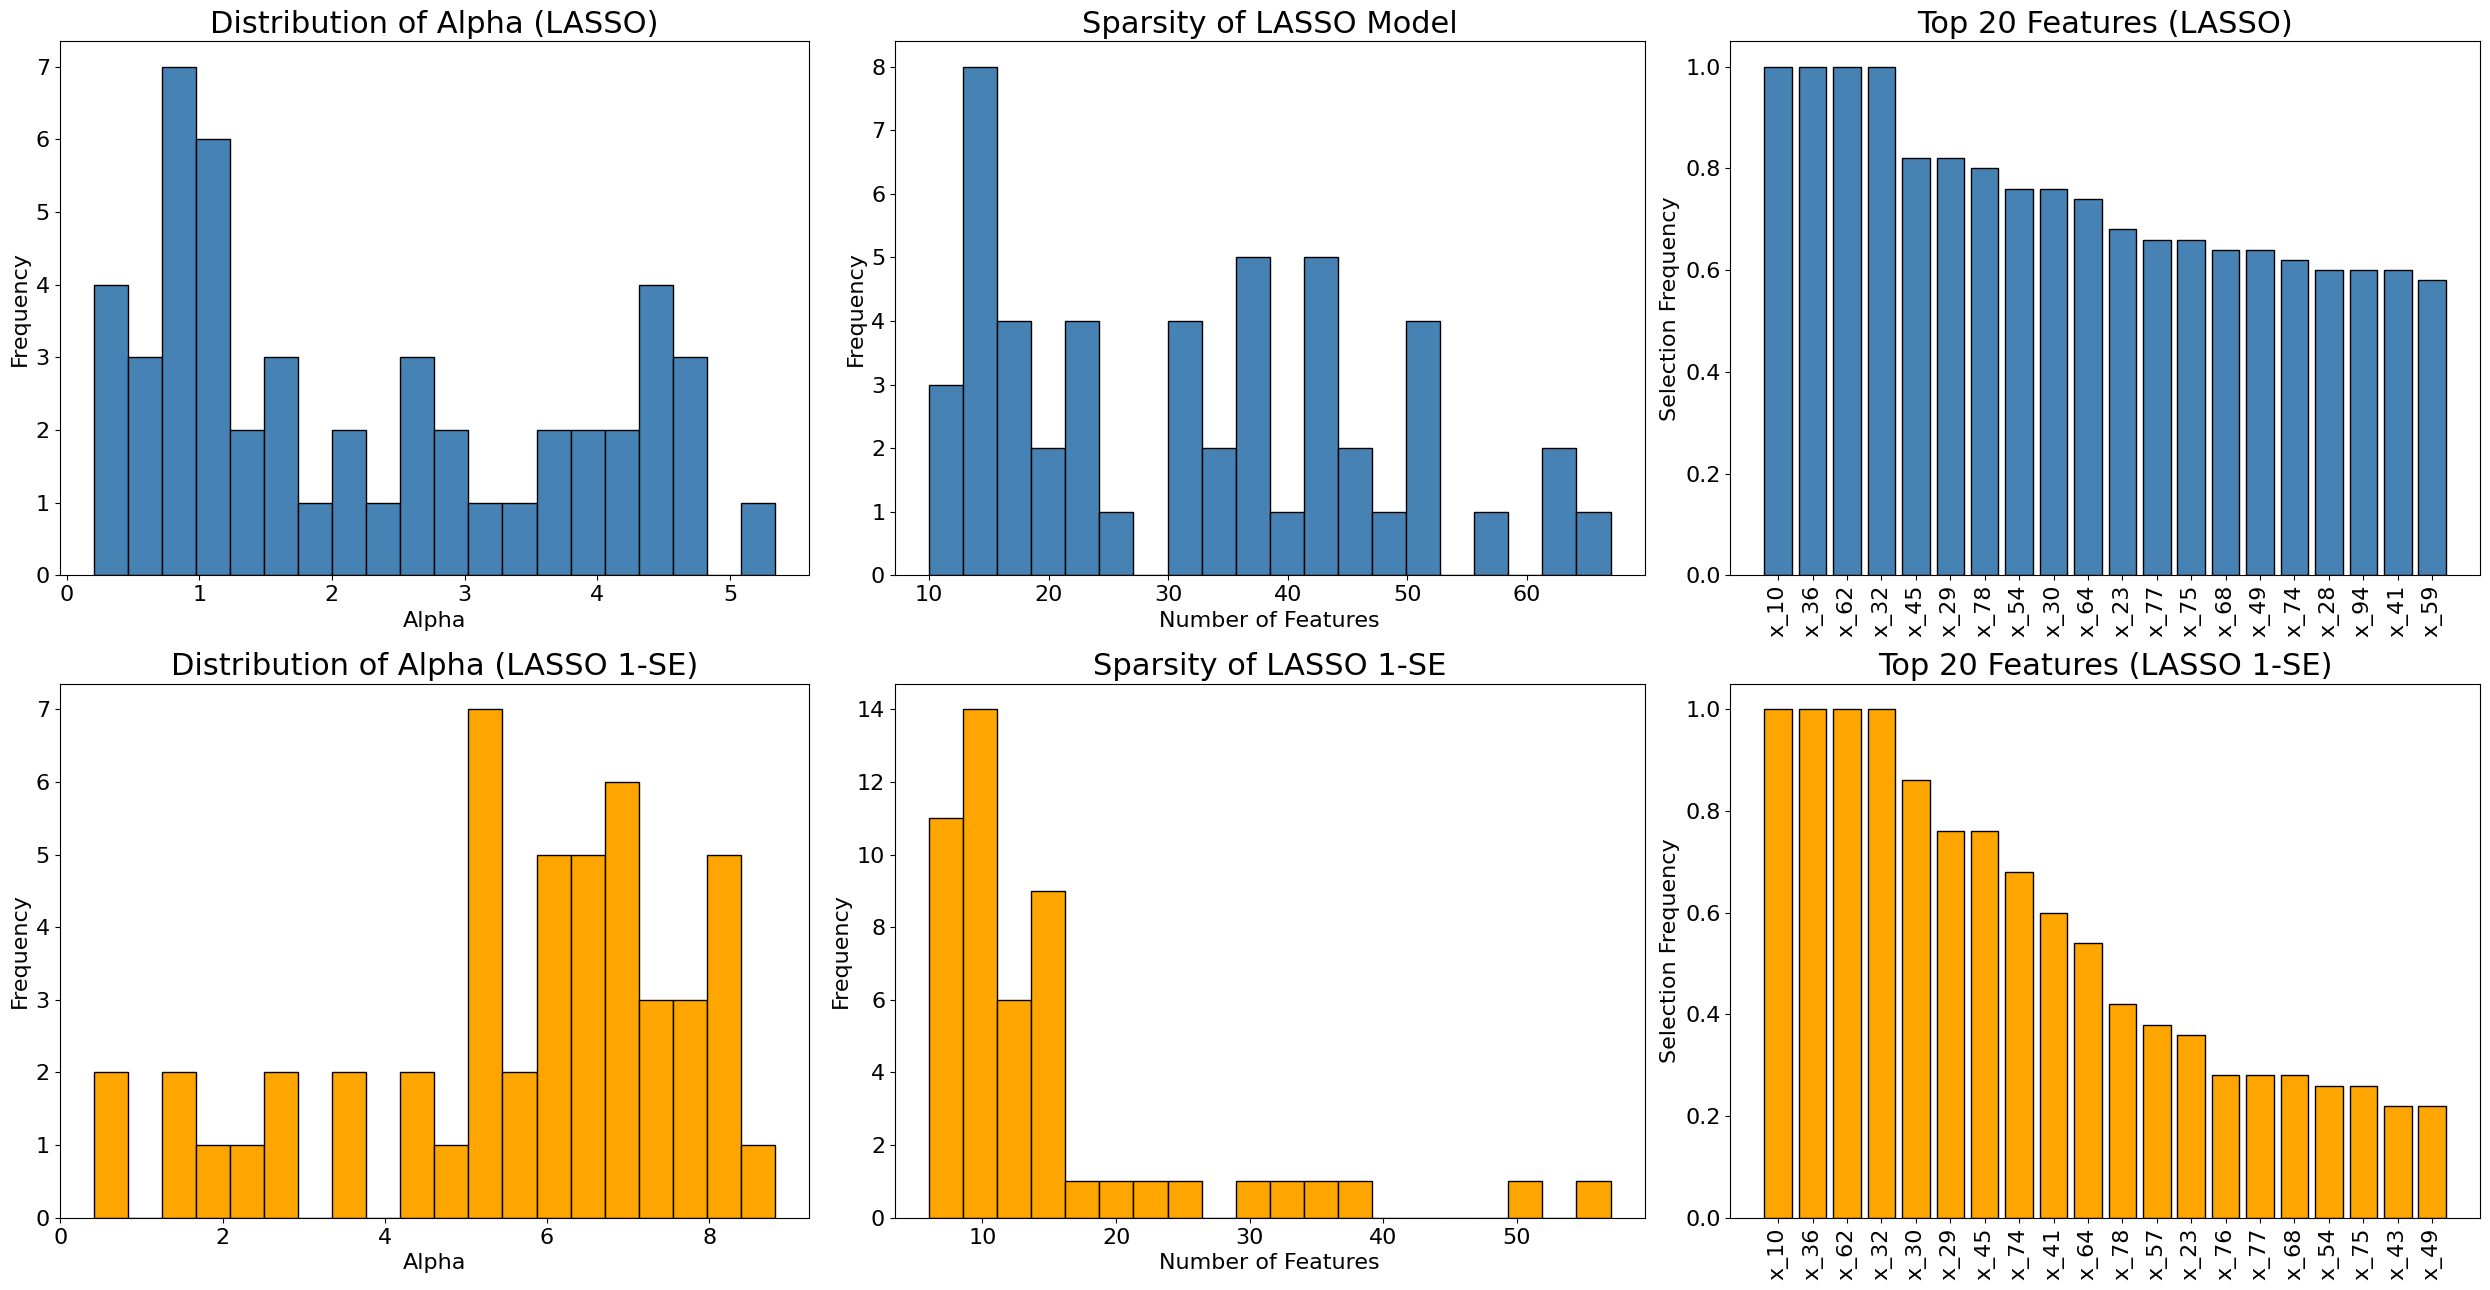

In [10]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns

# Prepare selection frequencies
selection_freq = selection_counts / 50
selection_freq_1se = selection_counts_1se / 50

# Sort top features
top_idx = np.argsort(selection_freq)[::-1][:20]
top_idx_1se = np.argsort(selection_freq_1se)[::-1][:20]

# Create a 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(25,13))

# ----- TOP ROW: Original Lasso -----
# 1. Distribution of selected alphas
axes[0,0].hist(best_alphas, bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_xlabel("Alpha", fontsize=16)
axes[0,0].set_ylabel("Frequency", fontsize=16)
axes[0,0].set_title("Distribution of Alpha (LASSO)", fontsize=22)
axes[0,0].tick_params(axis='both', labelsize=16)

# 2. Number of selected features
axes[0,1].hist(n_selected_list, bins=20, color='steelblue', edgecolor='black')
axes[0,1].set_xlabel("Number of Features", fontsize=16)
axes[0,1].set_ylabel("Frequency", fontsize=16)
axes[0,1].set_title("Sparsity of LASSO Model", fontsize=22)
axes[0,1].tick_params(axis='both', labelsize=16)

# 3. Top 20 most frequently selected features
axes[0,2].bar(range(20), selection_freq[top_idx], color='steelblue', edgecolor='black')
axes[0,2].set_xticks(range(20))
axes[0,2].set_xticklabels(feature_names[top_idx], rotation=90, fontsize=16)
axes[0,2].set_ylabel("Selection Frequency", fontsize=16)
axes[0,2].set_title("Top 20 Features (LASSO)", fontsize=22)
axes[0,2].tick_params(axis='y', labelsize=16)

# ----- BOTTOM ROW: 1-SE Lasso -----
# 1. Distribution of selected alphas
axes[1,0].hist(alphas_1se, bins=20, color='orange', edgecolor='black')
axes[1,0].set_xlabel("Alpha", fontsize=16)
axes[1,0].set_ylabel("Frequency", fontsize=16)
axes[1,0].set_title("Distribution of Alpha (LASSO 1-SE)", fontsize=22)
axes[1,0].tick_params(axis='both', labelsize=16)

# 2. Number of selected features
axes[1,1].hist(n_selected_list_1se, bins=20, color='orange', edgecolor='black')
axes[1,1].set_xlabel("Number of Features", fontsize=16)
axes[1,1].set_ylabel("Frequency", fontsize=16)
axes[1,1].set_title("Sparsity of LASSO 1-SE", fontsize=22)
axes[1,1].tick_params(axis='both', labelsize=16)

# 3. Top 20 most frequently selected features
axes[1,2].bar(range(20), selection_freq_1se[top_idx_1se], color='orange', edgecolor='black')
axes[1,2].set_xticks(range(20))
axes[1,2].set_xticklabels(feature_names[top_idx_1se], rotation=90, fontsize=16)
axes[1,2].set_ylabel("Selection Frequency", fontsize=16)
axes[1,2].set_title("Top 20 Features (LASSO 1-SE)", fontsize=22)
axes[1,2].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

## 4. ElasticNet

In [11]:
%reset

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.linear_model import Lasso

def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

In [13]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


In [14]:
X_np = X.values
y_np = y_class.values

# numerical columns to standardize
num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

# for the repetitions of the outer cv
repetitions_rmse = []

# save hyperparameters from model selection
best_alphas = []
best_ratios = []

# residual analysis
y_cv_true = []
y_cv_pred = []

# save selected features
n_selected_list = []
selection_counts = np.zeros(X.shape[1])

outer_folds = 5
n_repeats = 10

# change composition of folds
for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    folds_rmse = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]

        # impute numerical missing values using median of training fold
        X_out_train[:, num_idx] = np.where(
            np.isnan(X_out_train[:, num_idx]),
            np.nanmedian(X_out_train[:, num_idx], axis=0),
            X_out_train[:, num_idx]
        )
        # apply same median to test fold
        train_median = np.nanmedian(X_out_train[:, num_idx], axis=0)
        X_out_test[:, num_idx] = np.where(
            np.isnan(X_out_test[:, num_idx]),
            train_median,
            X_out_test[:, num_idx]
        )
        
        #for X: standardize only numerical features
        scaler = StandardScaler()
        X_out_train[:, num_idx] = scaler.fit_transform(X_out_train[:, num_idx])
        X_out_test[:, num_idx] = scaler.transform(X_out_test[:, num_idx])
        #for y: only center
        y_out_train_centered, mu = centerData(y_out_train)
        y_out_test_centered = y_out_test - mu

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            # automatic inner cv for model selection
            l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9,1]  # 1.0 = pure Lasso, 0.0 = Ridge
            # min rmse to get best lambda
            elastic_model = ElasticNetCV(l1_ratio=l1_ratios,alphas=None,cv=5,fit_intercept=False,max_iter=10000,n_jobs=-1)
            elastic_model.fit(X_out_train, y_out_train_centered)

        best_alpha = elastic_model.alpha_
        best_alphas.append(best_alpha)

        best_ratio = elastic_model.l1_ratio_
        best_ratios.append(best_ratio)

        # number of selected features
        coef_best = elastic_model.coef_
        selected = (coef_best != 0)
        n_selected_list.append(selected.sum())
        selection_counts += selected

        # evaluation on outer test set
        y_out_pred = X_out_test @ coef_best
        rmse_fold = np.sqrt(np.mean((y_out_pred - y_out_test_centered)**2))
        folds_rmse.append(rmse_fold)
        
        y_cv_true.extend(y_out_test_centered) 
        y_cv_pred.extend(y_out_pred)

    repetitions_rmse.extend(folds_rmse)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

print(f"Mean best_alpha: {np.mean(best_alphas):.4f}")
print(f"Std of best_alpha: {np.std(best_alphas):.4f}")

overall_std = np.std(repetitions_rmse)
print(f"Overall std: {overall_std:.4f}")

c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=

Repeated Nested CV estimated RMSE: 34.0240 ± 0.6071
Mean best_alpha: 2.1251
Std of best_alpha: 1.5483
Overall std: 4.2927


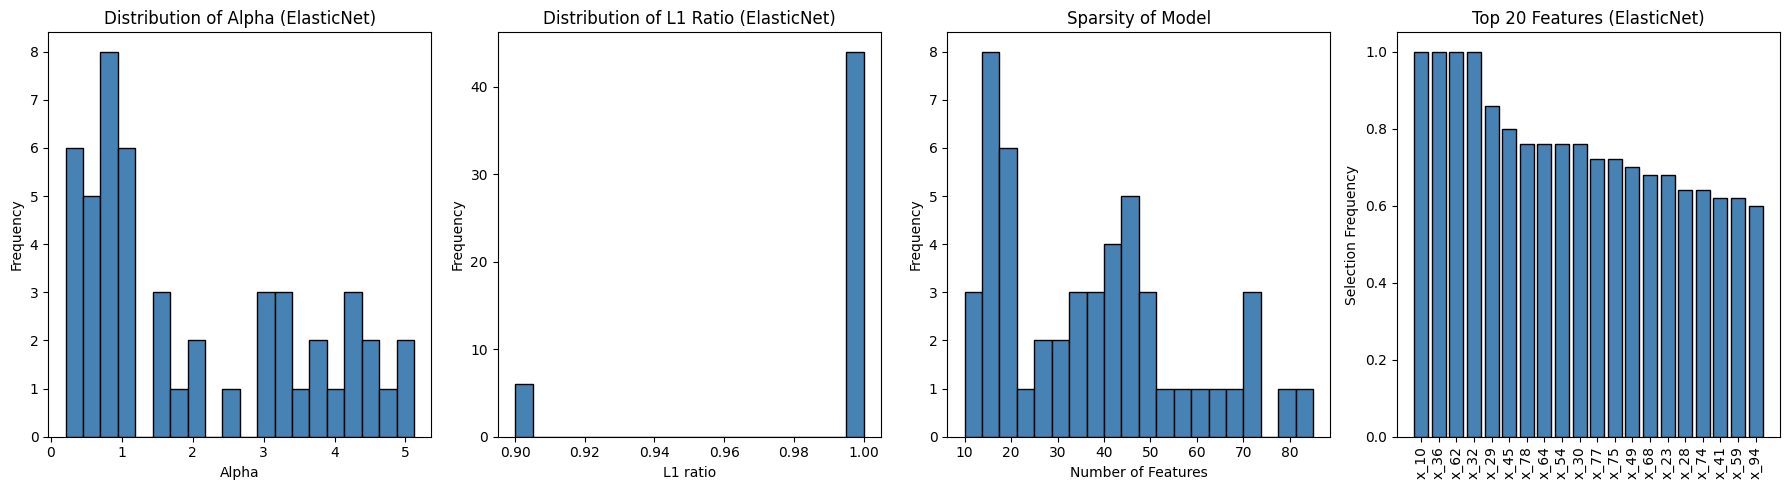

In [9]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns
selection_freq = selection_counts / 50
sorted_idx = np.argsort(selection_freq)[::-1]
top_idx = sorted_idx[:20]

# Create a 1x3 subplot figure
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# ----- Plot 1: Distribution of selected alphas -----
axes[0].hist(best_alphas, bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Alpha (ElasticNet)")

# ----- Plot 2: Distribution of selected L1 ratios -----
axes[1].hist(best_ratios, bins=20, color='steelblue', edgecolor='black')
axes[1].set_xlabel("L1 ratio")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of L1 Ratio (ElasticNet)")

axes[2].hist(n_selected_list, bins=20, color='steelblue', edgecolor='black')
axes[2].set_xlabel("Number of Features")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Sparsity of Model")

# ----- Plot 3: Top 20 most frequently selected features -----
axes[3].bar(range(20), selection_freq[top_idx], color='steelblue', edgecolor='black')
axes[3].set_xticks(range(20))
axes[3].set_xticklabels(feature_names[top_idx], rotation=90)
axes[3].set_ylabel("Selection Frequency")
axes[3].set_title("Top 20 Features (ElasticNet)")




plt.tight_layout()
plt.show()

## 5. RandomForest

In [15]:
%reset

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.linear_model import Lasso

def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

In [17]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)


categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
import numpy as np

X_np = X.values
y_np = y_class.values

# numerical columns to standardize
num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

#each row corresponds to each repetition rmse (5 values, 1 per fold)
repetitions_rmse = []
#feature importance per repetition
repetitions_fimp = []
best_params = []

#to check residuals after
y_cv_true = []
y_cv_pred = []

p = len(numerical_data)
m = p//3

param_grid = {
    'n_estimators': [100, 300, 500], #big number so we can reduce variance
    'max_depth': [3, 5, 10], #shallow trees so it doesnt overfit
    'min_samples_leaf': [5, 10], #not very small to prevent the tree from learning noise
    'max_features': ['sqrt', 'log2', m] #to decorrelate the trees 
}


n_repeats = 10
outer_folds = 5

#change composition of folds
for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)

    #saves 5 values per repetition, since we have 5 test sets
    folds_rmse = []
    folds_fimp = []

    #split data in 5 folds, 1 for test and 4 for hyperparameter tuning
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]

        X_out_train[:, num_idx] = np.where(
            np.isnan(X_out_train[:, num_idx]),
            np.nanmedian(X_out_train[:, num_idx], axis=0),
            X_out_train[:, num_idx]
        )
        # apply same median to test fold
        train_median = np.nanmedian(X_out_train[:, num_idx], axis=0)
        X_out_test[:, num_idx] = np.where(
            np.isnan(X_out_test[:, num_idx]),
            train_median,
            X_out_test[:, num_idx]
        )

        #trees minimize squared error when choosing were to split
        rf = RandomForestRegressor(
            criterion='squared_error',
            bootstrap=True,
            n_jobs=-1
        )

        #evaluates it with negative rmse
        grid = GridSearchCV(
            estimator=rf,
            param_grid=param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )

        grid.fit(X_out_train, y_out_train)

        #save best parameters
        best_model = grid.best_estimator_
        best_params.append(grid.best_params_)

        #save best models feature importance
        folds_fimp.append(best_model.feature_importances_)

        #predict on test set
        y_pred = best_model.predict(X_out_test)
        fold_rmse = np.sqrt(np.mean((y_pred - y_out_test)**2))
        folds_rmse.append(fold_rmse)

        y_cv_true.extend(y_out_test)
        y_cv_pred.extend(y_pred)

    repetitions_rmse.extend(folds_rmse)
    repetitions_fimp.append(folds_fimp)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
overall_std = np.std(repetitions_rmse)

print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")
print(f"Overall std: {overall_std:.4f}")

Repeated Nested CV estimated RMSE: 55.5430 ± 1.3847
Overall std: 9.7913


In [19]:
df_params = pd.DataFrame(best_params)
for col in df_params.columns:
    print(df_params[col].value_counts())
    print("\n")

max_depth
5     27
10    20
3      3
Name: count, dtype: int64


max_features
33    50
Name: count, dtype: int64


min_samples_leaf
5    50
Name: count, dtype: int64


n_estimators
100    22
500    14
300    14
Name: count, dtype: int64




In [ ]:
fimp = np.array(repetitions_fimp)         
fimp = fimp.reshape(-1, fimp.shape[2])  
fimp_df = pd.DataFrame(fimp, columns=X.columns)

mean_importance = fimp_df.mean(axis=0)
sorted_importance = mean_importance.sort_values(ascending=False)

plt.figure(figsize=(16, 6))
plt.bar(sorted_importance.index[:20], sorted_importance.values[:20])
plt.xticks(rotation=90)
plt.ylabel("Mean Feature Importance")
plt.show()

## 6. Final

In [66]:
%reset

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.linear_model import Lasso

In [68]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64
C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


In [69]:
def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

In [70]:
scaler = StandardScaler()
# numerical columns to standardize
num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]
X_scaled = X.values.copy()
X_scaled[:, num_idx] = scaler.fit_transform(X_scaled[:, num_idx])
y_centered, mu = centerData(y_class.values)

# select best alpha
lasso_final = LassoCV(cv=5, fit_intercept=False)
lasso_final.fit(X_scaled, y_centered)
best_alpha = lasso_final.alpha_
print(f"Selected alpha: {best_alpha}")

# see how many coefs are not zero
coef_final = lasso_final.coef_ 
non_zero_count = np.sum(coef_final != 0)
print(f"Number of non-zero coefficients: {non_zero_count}")

Selected alpha: 0.8631237087558815
Number of non-zero coefficients: 55


Alpha chosen by 1 SE rule: 5.6787776498015665
Number of non-zero coefficients (1 SE): 11


Alpha chosen by min CV MSE: 0.8631237087558815
Number of non-zero coefficients (min CV MSE): 55


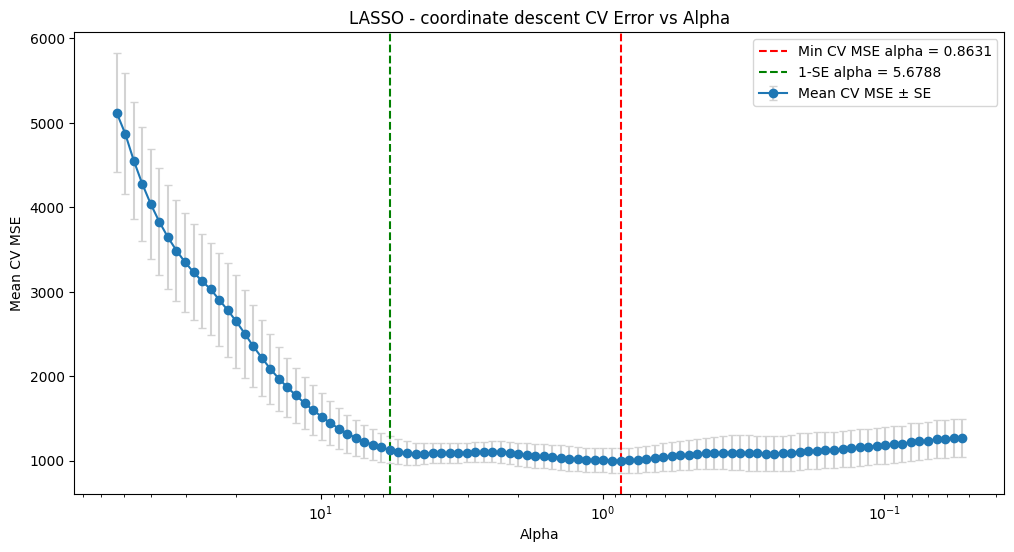

In [71]:
mse_path = lasso_final.mse_path_ 
mse_mean = np.mean(mse_path, axis=1)
mse_std = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])

min_idx = np.argmin(mse_mean)
min_mse = mse_mean[min_idx]
min_se = mse_std[min_idx]

threshold = min_mse + min_se

# find largest alpha with MSE <= threshold
alphas = lasso_final.alphas_
one_se_idx = np.where(mse_mean <= threshold)[0] 
alpha_1se = np.max(alphas[one_se_idx]) 

# coefs of 1se alpha
# refit on the full scaled data, coefs are not stored by lassolars cv
lasso_1se = Lasso(alpha=alpha_1se, fit_intercept=False)
lasso_1se.fit(X_scaled, y_centered)
coef_1se = lasso_1se.coef_
non_zero_1se = np.sum(coef_1se != 0)

print(f"Alpha chosen by 1 SE rule: {alpha_1se}")
print(f"Number of non-zero coefficients (1 SE): {non_zero_1se}")
print("\n")
print(f"Alpha chosen by min CV MSE: {best_alpha}")
print(f"Number of non-zero coefficients (min CV MSE): {non_zero_count}")


plt.figure(figsize=(12,6))
plt.errorbar(alphas, mse_mean, yerr=mse_std, fmt='-o', ecolor='lightgray', capsize=3,label='Mean CV MSE ± SE')
plt.axvline(best_alpha, color='red', linestyle='--',label=f'Min CV MSE alpha = {best_alpha:.4f}')
plt.axvline(alpha_1se, color='green', linestyle='--',label=f'1-SE alpha = {alpha_1se:.4f}')
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO - coordinate descent CV Error vs Alpha")
plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [72]:
# Boolean mask of selected features
selected_mask_1se = coef_1se != 0

# Get names of selected features
selected_features_1se = X.columns[selected_mask_1se]

# Get the corresponding coefficients
selected_coefs_1se = coef_1se[selected_mask_1se]

# Print feature names with coefficients
print("Features selected by LASSO 1-SE and their coefficients:")
for feat, coef in zip(selected_features_1se, selected_coefs_1se):
    print(f"{feat}: {coef:.4f}")

Features selected by LASSO 1-SE and their coefficients:
x_10: -5.7131
x_29: -1.6978
x_30: -4.3221
x_32: 50.2795
x_36: 16.9466
x_41: -1.2389
x_45: -2.8549
x_57: -0.3794
x_62: -20.2551
x_64: -0.3363
x_74: -2.4904


In [ ]:
y_pred_min = X_scaled @ coef_final # alpha_min
mse_train_min = np.sqrt(np.mean((y_pred_min - y_centered)**2))

y_pred_1se = X_scaled @ coef_1se 
mse_train_1se = np.sqrt(np.mean((y_pred_1se - y_centered)**2))

print(f"Train MSE (min CV alpha): {mse_train_min:.4f}")
print(f"Train MSE (1 SE alpha): {mse_train_1se:.4f}")

Train MSE (min CV alpha): 211.9426
Train MSE (1 SE alpha): 213.7050
